# VARIANCES

This notebook is dedicated at the empirical study of how the variance of the errors vary among different horizons.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

import plotly.express as px

In [10]:
from src.data_handler import *
from src.config_files import *
from src.direct_models import *
from src.mheme import *

In [11]:
WINDOW = 48
HORIZON = 12

DATA_PATH = '../data'

MODEL_PATH = '../models'

TCN_PATH_CONFIG_LOAD = '../src/config_files/tcn_config.json'
TCN_PATH_SAVE = '../models/tcn'

XGB_PATH_CONFIG_LOAD = '../src/config_files/xgb_config.json'
XGB_PATH_SAVE = '../models/xgb'

In [12]:
X, data = data_loader(data_path = DATA_PATH, dataset = 'electricity')

In [13]:
X_slide, y_slide = sliding_window(X, window=WINDOW, horizon=HORIZON)
train, val, test = train_validation_test_split(X_slide, y_slide)

In [15]:
uhmeme_tcn = UMHEMe.load_model(os.path.join(MODEL_PATH, 'tcn_electrical_1.pkl'))
#uhmeme_tcn = UMHEMe(HORIZON, WINDOW, model_class=TCN, config_path=TCN_PATH_CONFIG_LOAD)
#uhmeme_tcn.fit(train[0], train[1])

In [59]:
uhmeme_tcn.compute_weights(train[0], train[1])

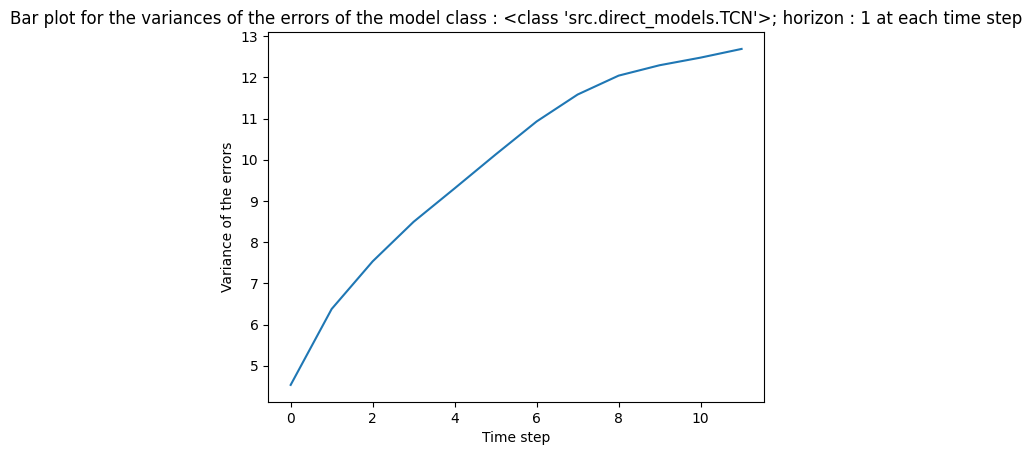

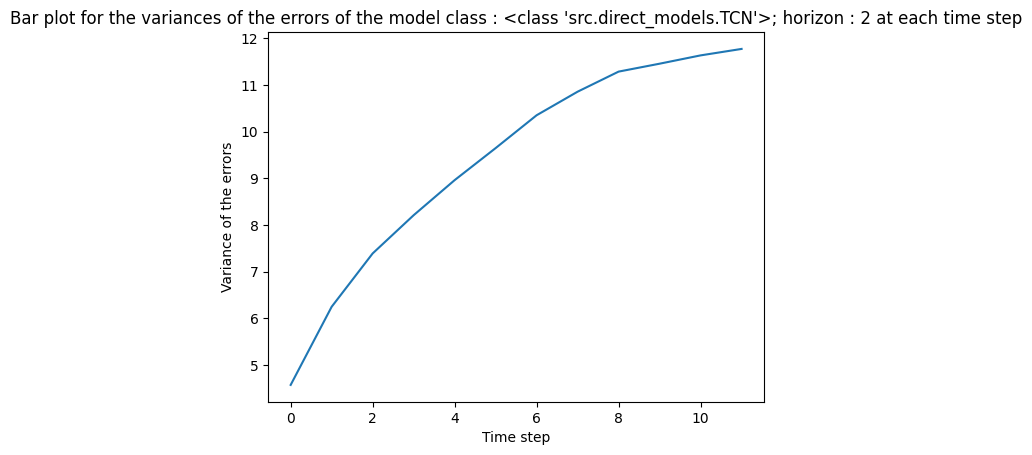

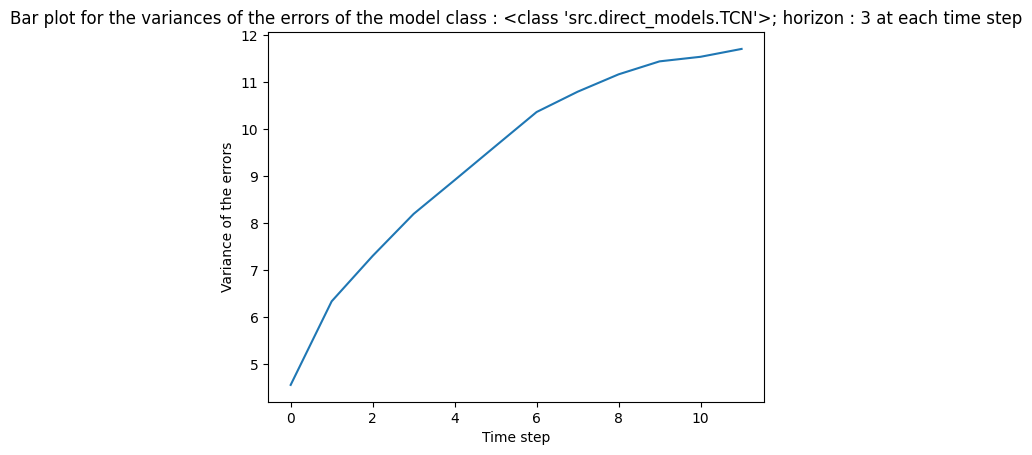

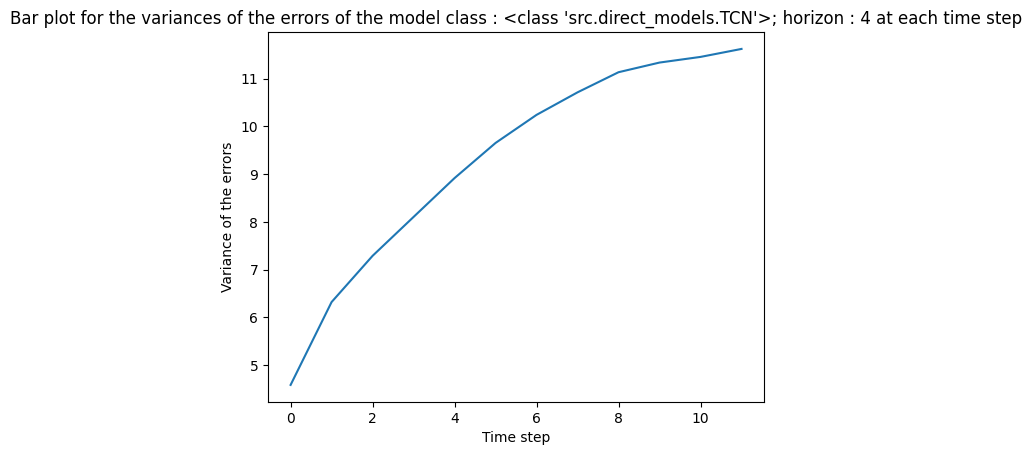

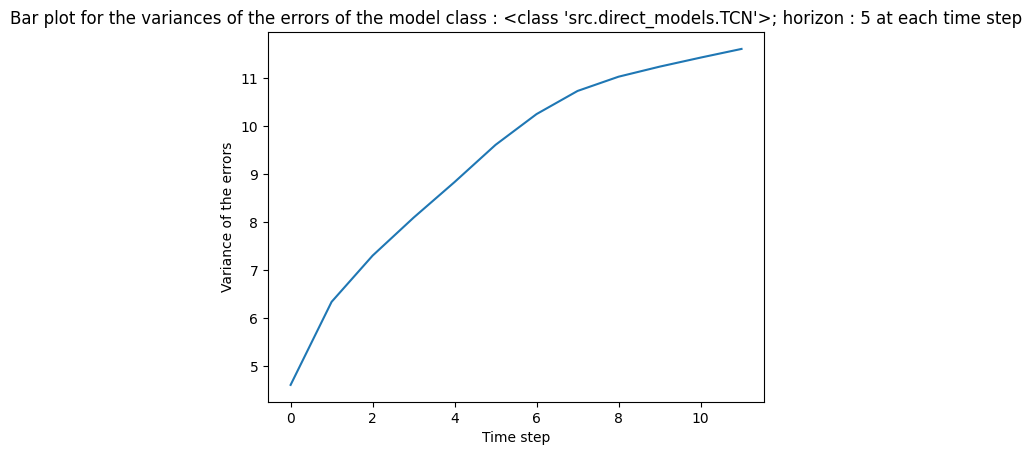

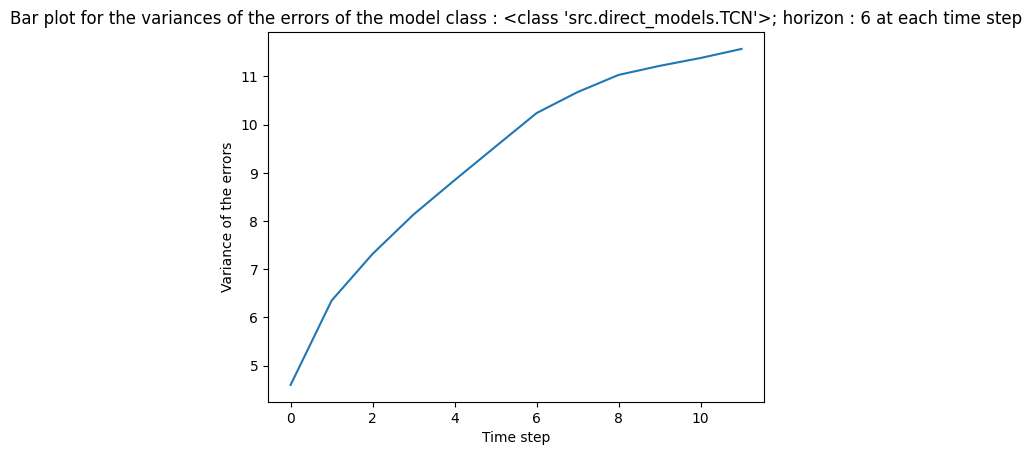

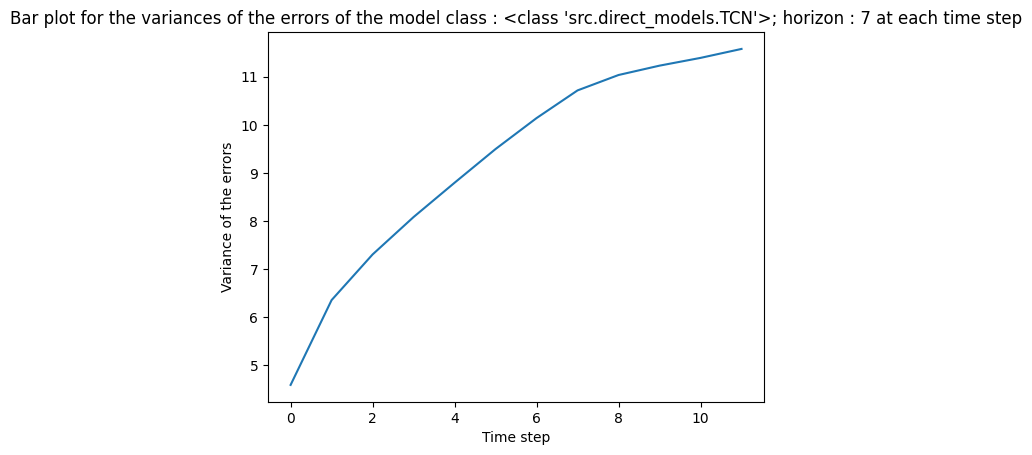

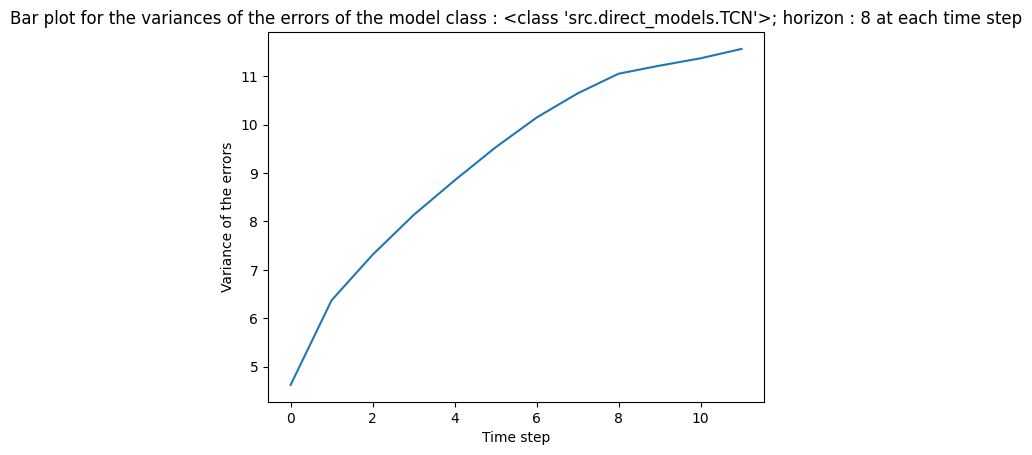

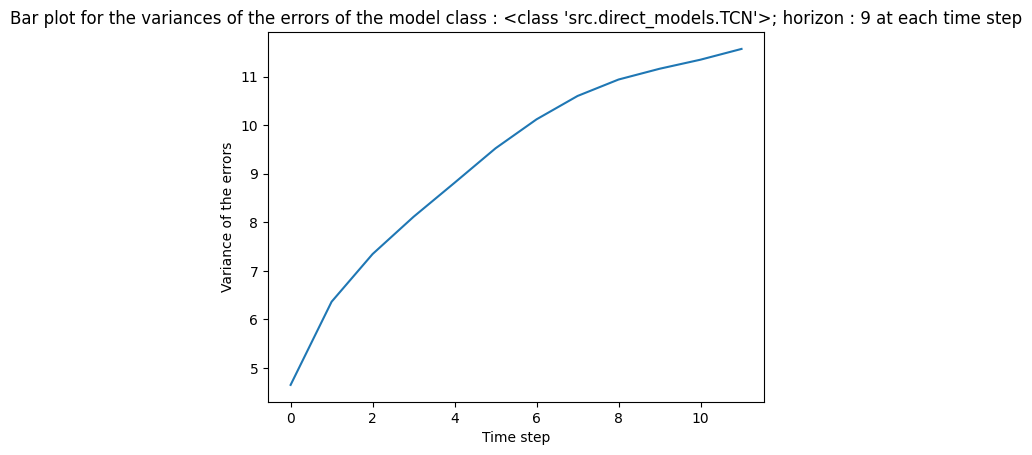

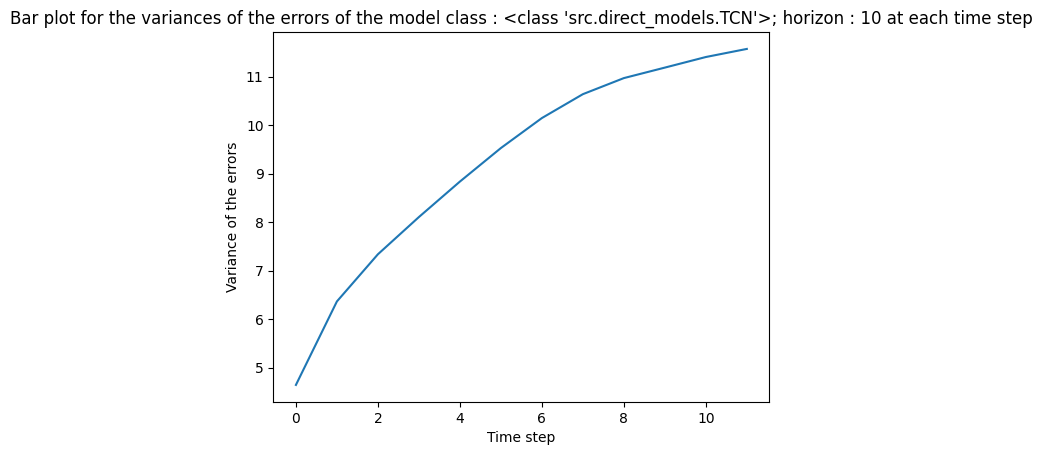

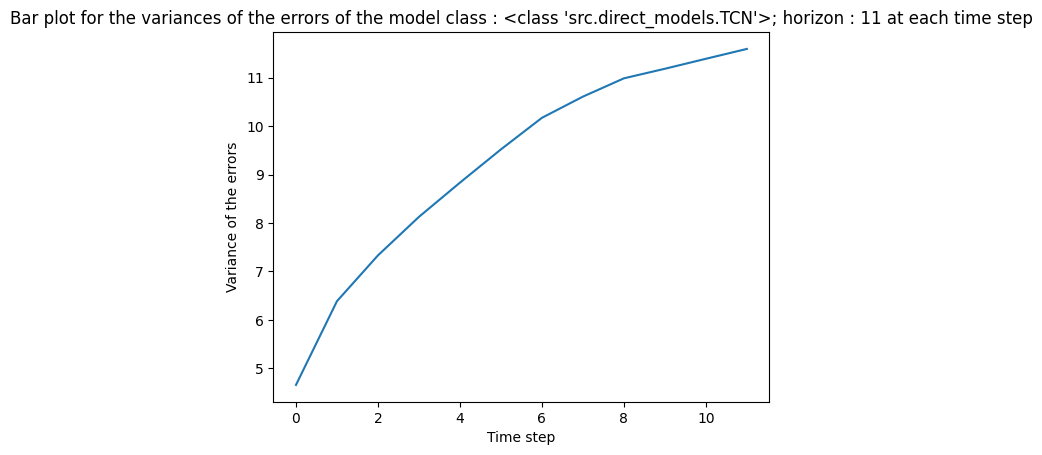

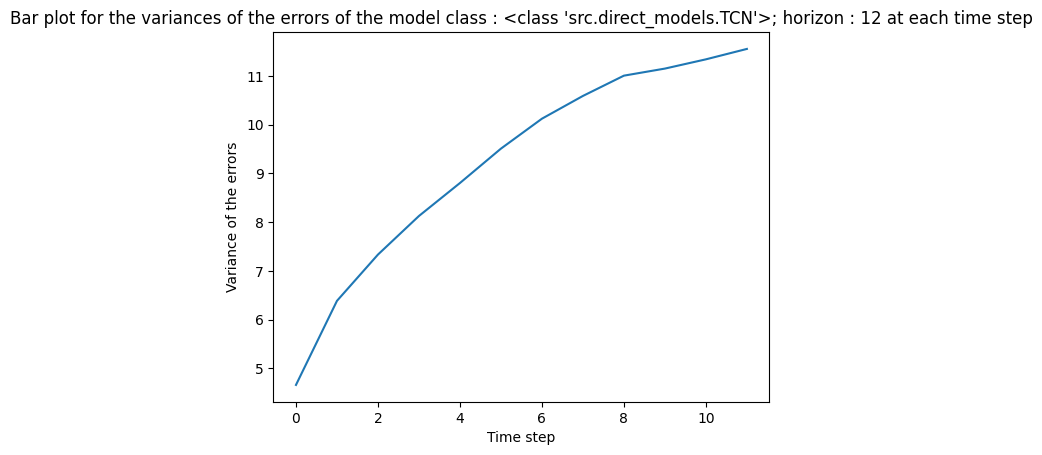

In [ ]:
uhmeme_tcn.visualize_variances(None)

In [58]:
uhmeme_tcn.predict(test[0])

array([[ 2.29137708,  2.39598931,  2.46116579, ...,  3.01129195,
         3.08591636,  3.16851037],
       [ 2.37965832,  2.48474727,  2.53644013, ...,  3.06171121,
         3.1312579 ,  3.21176039],
       [ 2.19176601,  2.34190705,  2.39651842, ...,  2.97585527,
         3.05217733,  3.13611239],
       ...,
       [16.56492779, 15.78843904, 15.19311221, ..., 11.90793866,
        11.5499083 , 11.16195732],
       [18.18975419, 16.89412726, 16.1904103 , ..., 12.5952081 ,
        12.256844  , 11.81345439],
       [16.13114379, 15.31427597, 14.66833379, ..., 11.50371589,
        11.20319787, 10.82678577]], shape=(1189, 12))